# TATA Online Retail Cleaning and EDA


## Import Required Libraries 

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Online Retail from TATA.csv')

df.shape

(541909, 8)

In [4]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/01/2010 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/01/2010 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/01/2010 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/01/2010 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/01/2010 08:34:00,1.69,13047.0,United Kingdom


In [5]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
print('Statistical Summary:')

df.describe()

Statistical Summary:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
print('Finding Duplicated:')

df.duplicated()

Finding Duplicated:


0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Length: 541909, dtype: bool

In [8]:
print(df.duplicated().sum())

5268


In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(536641, 8)

In [11]:
print('Finding Null Values')

df.isnull().sum()

Finding Null Values


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [12]:
# Handling null values

df['Description'] = df['Description'].fillna('Unknown Product')

In [13]:

df = df.fillna(0)

In [14]:
print('After handling null values:')

df.isnull().sum()

After handling null values:


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

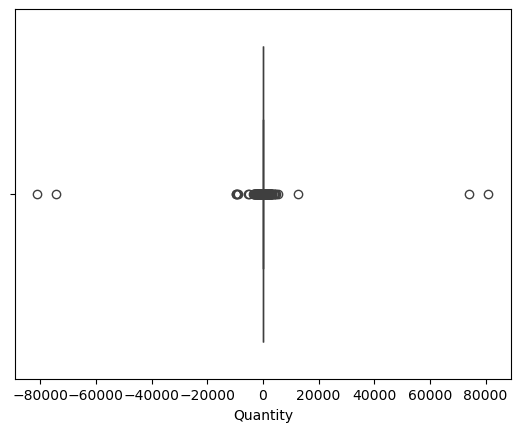

In [15]:
sns.boxplot(x=df['Quantity'])
plt.show()

# Remove outliers using IQR
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Quantity'] >= Q1 - 1.5*IQR) & (df['Quantity'] <= Q3 + 1.5*IQR)]

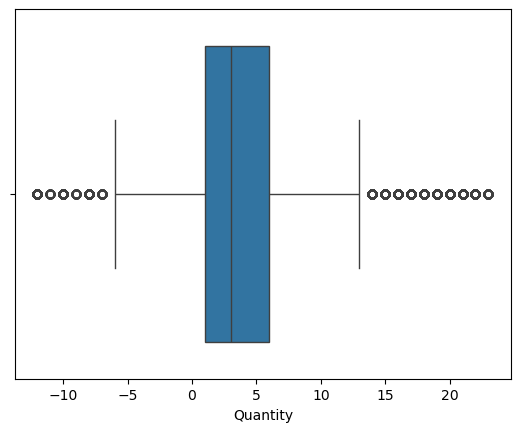

In [16]:
sns.boxplot(x=df['Quantity'])
plt.show()


Country
United Kingdom    442255
Germany             7934
France              7096
EIRE                6443
Spain               2175
Belgium             1807
Switzerland         1509
Portugal            1317
Norway               771
Italy                723
Name: count, dtype: int64

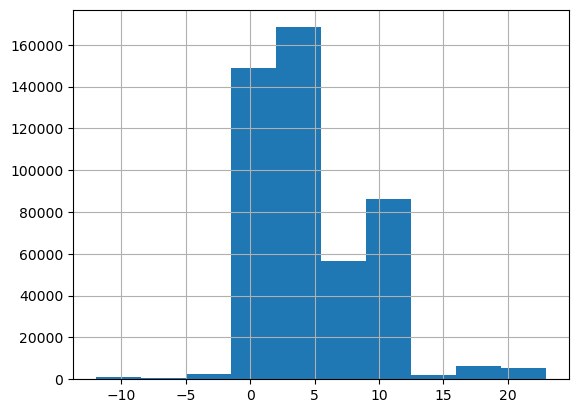

In [17]:
df['Quantity'].hist()

# Value counts
df['Country'].value_counts().head(10)

### What the chart shows
- The histogram represents how order quantities are distributed
- Most values are concentrated between 1 to 10 units
- There are very few large quantity orders (right tail)

### Key Insight:
   
Most transactions involve low quantities (1–5 items), indicating that customers mainly make small, individual purchases rather than bulk orders.

In [18]:
# Top countries
df.groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(10)

# Top customers
df.groupby('CustomerID')['Quantity'].sum().sort_values(ascending=False).head(10)

CustomerID
0.0        315172
14911.0     34950
17841.0     17231
14096.0     14420
13089.0     12396
12748.0     11839
14298.0      7077
13081.0      6905
15039.0      6780
14156.0      6510
Name: Quantity, dtype: int64

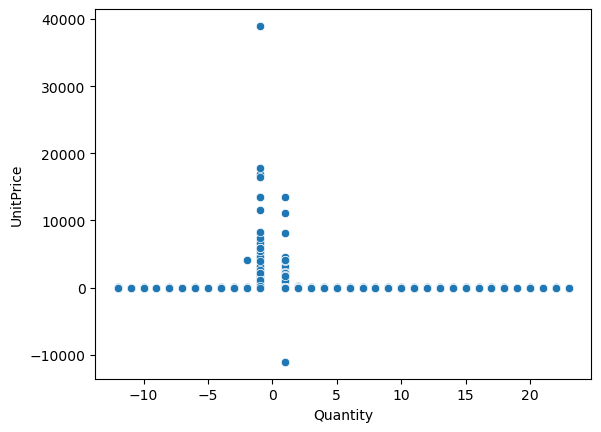

In [19]:
sns.scatterplot(x=df['Quantity'], y=df['UnitPrice'])
plt.show()

### Chart 
Quantity vs Unit Price (Scatter Plot)

### Key Insight:
There is no clear relationship between quantity and unit price, indicating that product pricing is independent of how many items are purchased, with some extreme outliers present.

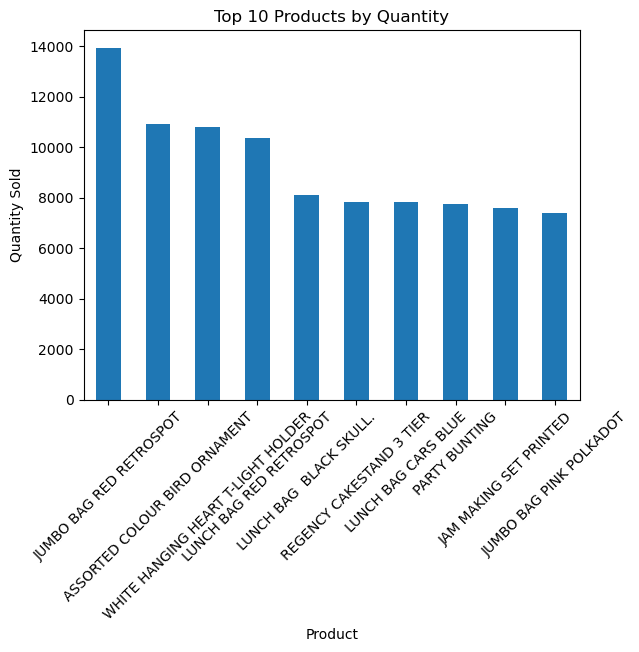

In [20]:
# Top 10 products by quantity
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Plot
top_products.plot(kind='bar')

plt.title("Top 10 Products by Quantity")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

### Chart 
Top 10 Products by Quantity

### Key Insights
- A few products dominate sales, with the top product significantly higher than others
- The sales difference between ranks gradually decreases after the top 3–4 products
- Indicates a high demand concentration on specific popular items

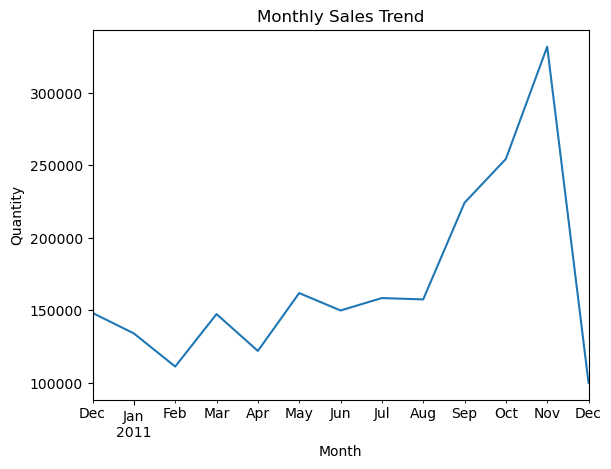

In [21]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create month column
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# Group by month
monthly_sales = df.groupby('Month')['Quantity'].sum()

# Plot
monthly_sales.plot(kind='line')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.show()

### Chart 
Monthly Sales Trend (Line Chart)
### Key Insights:

- Sales show a gradual upward trend over time
- Significant peak observed in the final months
- Sharp drop at the end indicates possible incomplete or partial data for that month

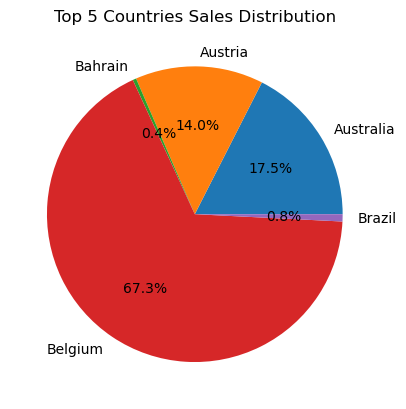

In [22]:
country_sales = df.groupby('Country')['Quantity'].sum().head(5)

# Plot
country_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Top 5 Countries Sales Distribution")
plt.ylabel("")
plt.show()

### Chart 

Top 5 Countries Sales Distribution (Pie Chart)
### Key Insights:


- One country (Belgium) dominates sales with a large majority share
- Other countries contribute significantly less, showing uneven distribution
- Some countries have very minimal contribution, indicating low market presence



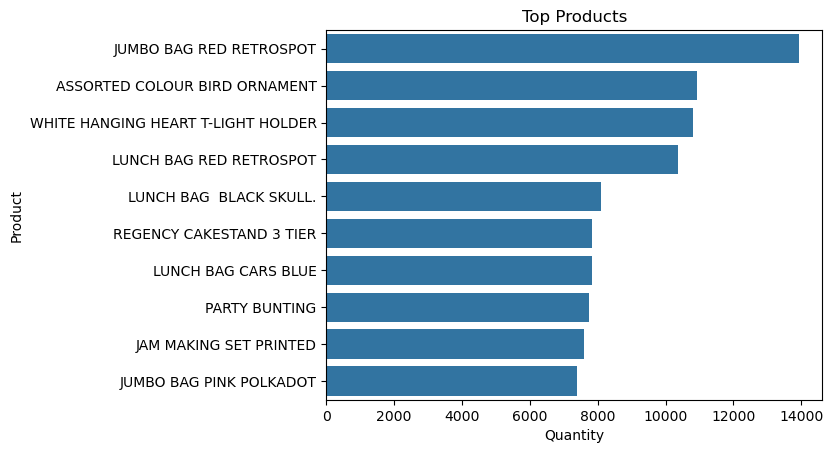

In [23]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top Products")
plt.xlabel("Quantity")
plt.ylabel("Product")
plt.show()

## Chart
Top Products by Quantity (Horizontal Bar Chart)
## Key Insights:

- One product clearly leads sales, showing significantly higher demand than others
- The top few products contribute the majority of total quantity sold
- Sales are concentrated among specific items, indicating strong product preference trends

## Project Summary

This project focuses on cleaning and preparing a real-world online retail dataset to ensure it is reliable and ready for analysis. Using Python, key preprocessing steps were performed to improve data quality and structure.

The workflow began with loading the dataset and performing initial exploration to understand its shape, data types, and missing values. Duplicate records were identified and removed to maintain data integrity. Missing values were handled appropriately, and irrelevant or inconsistent entries—such as negative quantities or prices—were filtered out.

Data types were corrected where necessary (e.g., converting date columns into proper datetime format), enabling accurate time-based analysis. Additional transformations were applied to enhance usability, such as creating new features like total price (Quantity × UnitPrice).

Overall, this project demonstrates essential data preprocessing techniques using libraries like Pandas and NumPy. The cleaned dataset is now structured, consistent, and ready for further analysis, visualization, or machine learning tasks.